In [29]:
import pandas as pd
import numpy as np

df=pd.read_csv("../customer_behavior_cleaned.csv")

df.head()

# Can we predict whether a customer will subscribe based on their characteristics and shopping behaviour?

# This is a classification problem because the outcome has two categories:

# Yes
# No

# Our target variable will therefore be:
# subscription_status



,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle_Aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young_Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle_Aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young_Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle_Aged,365


In [30]:

df['subscription_status'].value_counts()


# now checking for percentage distribution whether they are equal or not 

df['subscription_status'].value_counts(normalize=True) * 100

# So we have class imbalance: about 73% non-subscribers and 27% subscribers.

subscription_status
No     73.0
Yes    27.0
Name: proportion, dtype: float64

In [31]:
# Step 3 — Separate features (X) and target (y)
# We want the model to learn:

# customer information → subscription status
# So:

# X = information about the customer
# y = subscription_status (what we want to predict)

# Run this next:

X = df.drop(['subscription_status', 'customer_id'], axis=1)

y = df['subscription_status']


print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (3900, 18)
y shape: (3900,)


,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Express,Yes,Yes,14,Venmo,Fortnightly,Middle_Aged,14
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Express,Yes,Yes,2,Cash,Fortnightly,Young_Adult,14
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle_Aged,7
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young_Adult,7
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle_Aged,365


In [32]:
# One important thing

# Your X still contains text columns such as:

# gender
# item_purchased
# category
# location
# size
# color
# season
# shipping_type
# discount_applied
# promo_code_used
# ...

# A machine-learning algorithm such as Logistic Regression cannot directly work with these text values.

# So our next step is Encoding Categorical Variables.

# We will use One-Hot Encoding for categorical columns.

In [33]:
# Step 4 — Convert categorical columns into numbers

# We have many text columns in X, for example:

# gender
# item_purchased
# category
# location
# size
# color
# season
# shipping_type
# discount_applied
# promo_code_used
# payment_method
# frequency_of_purchases
# age_group

# ML models need numerical input, so we'll use One-Hot Encoding.

from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = X.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['gender', 'item_purchased', 'category', 'location', 'size', 'color',
       'season', 'shipping_type', 'discount_applied', 'promo_code_used',
       'payment_method', 'frequency_of_purchases', 'age_group'],
      dtype='str')


C:\Users\Arpith Poojary\AppData\Local\Temp\ipykernel_34712\1113470933.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns


In [34]:
# Performing one hot encoding
# One-Hot Encoding

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Suppose we have:

# Gender
# ------
# Male
# Female

# Without drop_first=True, one-hot encoding creates:

# gender_Male   gender_Female
# 1             0
# 0             1

# But notice something: if gender_Male = 0, we already know the person is Female.

# So we don't actually need both columns.

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

X_encoded.head()

Original X shape: (3900, 18)
Encoded X shape: (3900, 133)


,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days,gender_Male,item_purchased_Belt,item_purchased_Blouse,item_purchased_Boots,item_purchased_Coat,...,payment_method_Venmo,frequency_of_purchases_Bi-Weekly,frequency_of_purchases_Every 3 Months,frequency_of_purchases_Fortnightly,frequency_of_purchases_Monthly,frequency_of_purchases_Quarterly,frequency_of_purchases_Weekly,age_group_Middle_Aged,age_group_Senior,age_group_Young_Adult
0,55,53,3.1,14,14,True,False,True,False,False,...,True,False,False,True,False,False,False,True,False,False
1,19,64,3.1,2,14,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,50,73,3.1,23,7,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,21,90,3.5,49,7,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
4,45,49,2.7,31,365,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [35]:
# Step 5 — Train/Test Split

# Now we need to divide our data into:

# Training data → model learns from this
# Testing data → we use this to check whether the model works on unseen customers.

# We'll use the standard 80/20 split:

# 80% → training
# 20% → testing

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# stratify=y makes sure that approximately the same 73/27 proportion is maintained in both training and testing data.
# That's a good practice here because our target classes are imbalanced.

X_train: (3120, 133)
X_test: (780, 133)
y_train: (3120,)
y_test: (780,)


What we have done so far is :
Step 1 → Load & understand data
Step 2 → Check target distribution
Step 3 → Separate X and y
Step 4 → Encode categorical variables
Step 5 → Train/Test Split ✅

In [37]:
# Step 6 — Feature Scaling

# Our numerical features have very different ranges.

# For example:

# age                  → 18–70
# purchase_amount      → 20–100
# previous_purchases   → 1–50
# purchase_frequency   → 7–365

# If we use a model such as Logistic Regression, having features on very different scales can affect the model.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3120, 133)
X_test_scaled shape: (780, 133)


In [38]:
# First model: Logistic Regression
# Don't let the name confuse you.

# Logistic Regression is mainly used for classification, especially when the target has two classes.

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train) #this is where model learns pattern 

print("Model training completed.")

Model training completed.


In [39]:
# Step 8 — Make predictions

y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'Yes' 'Yes' 'No' 'No']


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

# "I treated subscribed customers as the positive class because the business is interested in identifying customers who are likely to subscribe."
# “I built a classification model to predict whether a customer is likely to subscribe. I evaluated it using accuracy, precision, recall and F1-score. The model achieved 98.2% accuracy and an F1-score of 96.7%, indicating strong predictive performance.”


Accuracy : 0.846
Precision: 0.681
Recall   : 0.81
F1 Score : 0.74


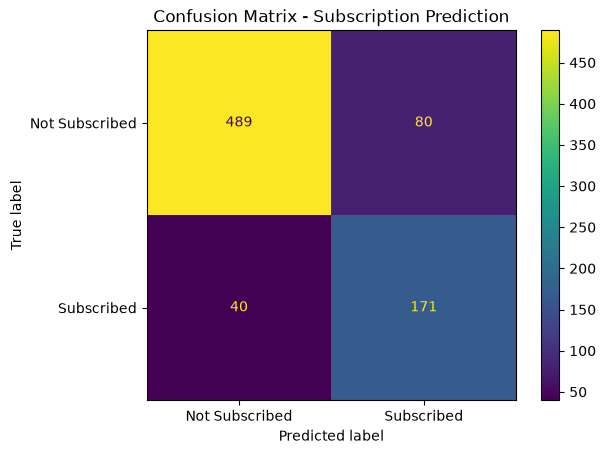

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['No', 'Yes'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Subscribed', 'Subscribed']
)

disp.plot()
plt.title("Confusion Matrix - Subscription Prediction")
plt.show()

# Actual       Predicted Not Subscribed	 Predicted Subscribed
# Not Subscribed	489	                  80
# Subscribed	    40	                 171

# What each number means
# 489 → True Negative (TN): Correctly identified non-subscribers.
# 80 → False Positive (FP): Model predicted "Subscribed", but they actually didn't subscribe.
# 40 → False Negative (FN): Model predicted "Not Subscribed", but they actually subscribed.
# 171 → True Positive (TP): Correctly identified subscribers

"The model identifies most potential subscribers, but some customers predicted as potential subscribers may not actually subscribe. Therefore, the model can be useful for targeting, but improving precision could reduce unnecessary marketing efforts."

In [42]:
# feature importance coeeficient
# Which customer characteristics are actually influencing the prediction of subscription?
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
118,promo_code_used_Yes,1.924473,1.924473
117,discount_applied_Yes,1.924473,1.924473
5,gender_Male,0.445897,0.445897
130,age_group_Middle_Aged,0.225820,0.225820
0,age,-0.183139,0.183139
48,location_Kentucky,0.161344,0.161344
77,location_Virginia,0.153543,0.153543
59,location_Nevada,0.152254,0.152254
37,location_Colorado,0.145453,0.145453
39,location_Delaware,0.145239,0.145239


But our model is giving customer_id an enormous coefficient compared with the other features. That means the model is probably using the ID to learn patterns that shouldn't be there.

So our earlier 98.2% accuracy cannot yet be treated as a trustworthy business result.

This is actually a very good learning point for your project because in a real Data Science interview, they may ask:

"How did you make sure there was no data leakage or irrelevant feature influencing your model?"

And we can demonstrate that we checked it. So now we have removed the customerid


🚨 And this teaches us something very important

Our previous 98.2% accuracy was misleading because customer_id was included.

After removing it:

98.2% → 84.6%

That is a huge drop.

This means the model was relying heavily on the customer ID, which is not a genuine behavioural feature. We should use the new model, not the 98.2% model.

And honestly, this makes your project more credible, because we're actually checking model reliability instead of blindly accepting a high accuracy.

What do these new numbers mean?
Accuracy — 84.6%

The model correctly predicts subscription status for about 85 out of every 100 customers.

Precision — 68.1%

When the model says:

"This customer is likely to subscribe"

it's correct about 68% of the time.

Recall — 81%

Out of all the customers who actually subscribed, our model successfully identifies about 81%.

This is particularly useful for our business problem because we don't want to miss too many potential subscribers.

F1 — 74%

F1 balances precision and recall.

74% is a reasonable starting point, but we can try to improve it.

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree trained successfully.")

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Predictions:")
print(y_pred_dt[:20])

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, pos_label='Yes')
recall_dt = recall_score(y_test, y_pred_dt, pos_label='Yes')
f1_dt = f1_score(y_test, y_pred_dt, pos_label='Yes')

print("Decision Tree")
print("Accuracy :", round(accuracy_dt, 3))
print("Precision:", round(precision_dt, 3))
print("Recall   :", round(recall_dt, 3))
print("F1 Score :", round(f1_dt, 3))

Decision Tree trained successfully.
Decision Tree Predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'Yes' 'No' 'No' 'No']
Decision Tree
Accuracy : 0.844
Precision: 0.67
Recall   : 0.829
F1 Score : 0.742


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [48]:
# Step 2 — Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Predictions:")
print(y_pred_rf[:20])

# Step 3 — Evaluate Random Forest

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label='Yes')
recall_rf = recall_score(y_test, y_pred_rf, pos_label='Yes')
f1_rf = f1_score(y_test, y_pred_rf, pos_label='Yes')

print("Random Forest")
print("Accuracy :", round(accuracy_rf, 3))
print("Precision:", round(precision_rf, 3))
print("Recall   :", round(recall_rf, 3))
print("F1 Score :", round(f1_rf, 3))

Random Forest Predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'Yes' 'Yes' 'No' 'No']
Random Forest
Accuracy : 0.863
Precision: 0.665
Recall   : 0.995
F1 Score : 0.797


In [49]:
print('customer_id' in X.columns)

False


In [50]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf.head(15)

,Feature,Importance
118,promo_code_used_Yes,0.251000
117,discount_applied_Yes,0.249620
5,gender_Male,0.084440
3,previous_purchases,0.030311
1,purchase_amount,0.028563
0,age,0.026895
2,review_rating,0.024656
4,purchase_frequency_days,0.011432
82,size_M,0.006045
110,season_Summer,0.006013
